# TS1 —  Síntesis y operaciones de señales

## Ejercicio 1 — Síntesis de señales

### Parámetros comunes

Todas las señales comparten la misma grilla temporal: $N = 1000$ muestras a una frecuencia de muestreo $f_s$.

Elección de $f_s$. La consigna pide al menos 10 puntos por período para la sinusoide de 2 kHz, es decir $f_s \ge 10 \cdot f_0 = 20\ \text{kHz}$. Se elige $f_s = 40\ \text{kHz}$, que cumple tres condiciones útiles:

- Da $f_s/f_0 = 20$ muestras por período, con holgura sobre el mínimo pedido.
- La resolución espectral resulta $\Delta f = f_s/N = 40\ \text{Hz}$, y $f_0 = 2000\ \text{Hz}$ cae exactamente en el bin $k = 50$. Al entrar un número entero de períodos en la ventana de observación, la DFT no presenta dispersión espectral y el espectro de la sinusoide es una única raya limpia.
- Las 20 muestras por período son un número par, de modo que el semiperíodo son exactamente 10 muestras.


| Parámetro | Símbolo | Valor |
|---|---|---|
| Cantidad de muestras | $N$ | 1000 |
| Frecuencia de muestreo | $f_s$ | 40 000 Hz |
| Tiempo entre muestras | $T_s = 1/f_s$ | 25 µs |
| Tiempo total observado | $N \cdot T_s$ | 25 ms |
| Resolución espectral | $\Delta f = f_s/N$ | 40 Hz |
| Frecuencia de Nyquist | $f_s/2$ | 20 000 Hz |

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import square, sawtooth

N  = 1000
fs = 40000
ts = 1 / fs
df = fs / N

tt = np.arange(N) * ts
ff = np.arange(N) * df

f0 = 2000
T0 = 1 / f0

rng = np.random.default_rng(seed=42)

### Funciones auxiliares

Se define una única función que grafica cada señal en el dominio del tiempo junto con el módulo de su transformada de Fourier, para no repetir código en cada ítem.

La DFT se normaliza dividiendo por $N$:

$$X[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]\, e^{-j2\pi kn/N}$$

Con esta normalización una sinusoide de amplitud $A$ produce dos rayas de módulo $A/2$ (una en $+f_0$ y su espejo en $-f_0$), lo que permite leer amplitudes directamente del espectro.

In [38]:
def potencia(xx):
    """Potencia media en el dominio del tiempo: P = (1/N)*sum(|x[n]|^2)."""
    return np.mean(np.abs(xx) ** 2)


def fft_norm(xx):
    """DFT normalizada por N, para que |X[k]| quede en unidades de amplitud."""
    return np.fft.fft(xx) / len(xx)


def analizar(xx, titulo, color='steelblue', ciclos=4, escala='lineal'):
    """Grafica la señal en el tiempo y el modulo de su transformada de Fourier."""
    XX    = fft_norm(xx)
    bfrec = ff <= fs / 2

    fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))

    # ---------- dominio del tiempo ----------
    ax[0].plot(tt * 1e3, xx, color=color, linewidth=1.4)
    ax[0].set_title(f'{titulo} — dominio del tiempo')
    ax[0].set_xlabel('Tiempo [ms]')
    ax[0].set_ylabel('Amplitud [V]')
    if ciclos is not None:
        ax[0].set_xlim([0, ciclos * T0 * 1e3])
    ax[0].grid(True, linestyle='--', alpha=0.5)

    # ---------- modulo de la transformada ----------
    mod = np.abs(XX[bfrec])
    if escala == 'dB':
        ax[1].plot(ff[bfrec] / 1e3, 20 * np.log10(np.maximum(mod, 1e-12)),
                   color=color, linewidth=1.2)
        ax[1].set_ylabel('|X(f)| [dB]')
        ax[1].set_ylim([-90, 10])
    else:
        ax[1].plot(ff[bfrec] / 1e3, mod, color=color, linewidth=1.2)
        ax[1].set_ylabel('|X(f)| [V]')
    ax[1].set_title(f'{titulo} — modulo de la TF')
    ax[1].set_xlabel('Frecuencia [kHz]')
    ax[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f'Potencia media P = {potencia(xx):.4f} W'
          f'   |   Valor medio (DC) = {np.mean(xx):+.4f} V'
          f'   |   Varianza = {np.var(xx):.4f} W')

### 1.1 — Señal sinusoidal de 2 kHz con al menos 10 puntos por período

$$x_1(t) = A_1 \sin(2\pi f_0 t), \qquad A_1 = 1\ \text{V}, \quad f_0 = 2\ \text{kHz}$$

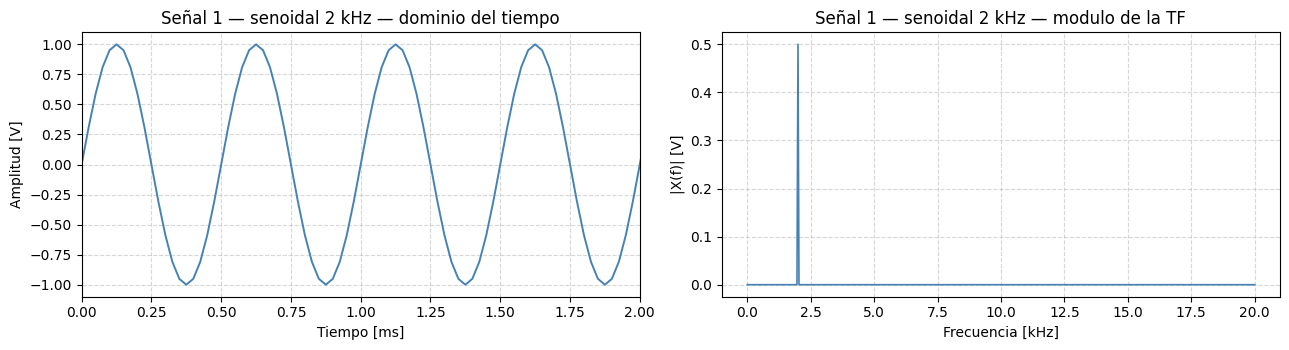

Potencia media P = 0.5000 W   |   Valor medio (DC) = -0.0000 V   |   Varianza = 0.5000 W
Muestras por periodo: 20   |   Pico del espectro: 0.5000 V (= A1/2)


In [39]:
A1  = 1.0
xx1 = A1 * np.sin(2 * np.pi * f0 * tt)

analizar(xx1, 'Señal 1 — senoidal 2 kHz', color='steelblue')
print(f'Muestras por periodo: {fs/f0:.0f}   |   Pico del espectro: {np.max(np.abs(fft_norm(xx1))):.4f} V (= A1/2)')

**Análisis — Señal 1**

| Parámetro | Valor |
|---|---|
| Período | $T_0 = 1/f_0 = 0{,}5$ ms |
| Muestras totales | $N = 1000$ |
| Muestras por período | $f_s/f_0 = 20$ ✔ (consigna: $\ge 10$) |
| Potencia media | $P = A_1^2/2 = 0{,}5$ W |
| Tipo de señal | Potencia |

### 1.2 — Misma señal con 2 W de potencia media y desfasada en $\pi/2$

Para una sinusoide la potencia media vale $P = A^2/2$. Imponiendo $P = 2$ W:

$$A_2 = \sqrt{2P} = \sqrt{4} = 2\ \text{V}$$

Respecto de la señal 1 ($A_1 = 1$ V, $P_1 = 0{,}5$ W) esto equivale a una ganancia de $10\log_{10}(2/0{,}5) = 6{,}02$ dB.

$$x_2(t) = 2 \sin\!\left(2\pi f_0 t + \tfrac{\pi}{2}\right) = 2\cos(2\pi f_0 t)$$

Amplitud necesaria: A2 = sqrt(2*2.0) = 2.00 V
Ganancia respecto de la señal 1: 6.02 dB


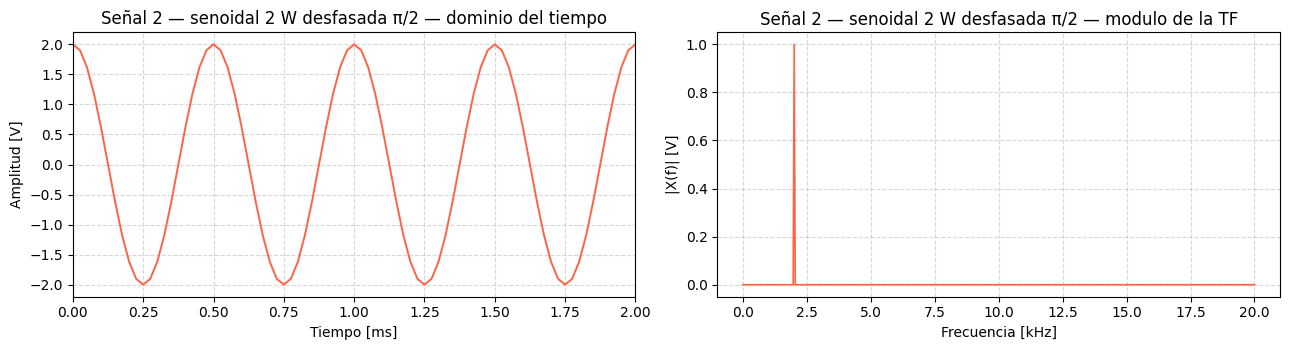

Potencia media P = 2.0000 W   |   Valor medio (DC) = -0.0000 V   |   Varianza = 2.0000 W


In [40]:
P2  = 2.0
A2  = np.sqrt(2 * P2)
ph2 = np.pi / 2

xx2 = A2 * np.sin(2 * np.pi * f0 * tt + ph2)

print(f'Amplitud necesaria: A2 = sqrt(2*{P2}) = {A2:.2f} V')
print(f'Ganancia respecto de la señal 1: {10*np.log10(potencia(xx2)/potencia(xx1)):.2f} dB')

analizar(xx2, 'Señal 2 — senoidal 2 W desfasada π/2', color='tomato')

**Análisis — Señal 2**

| Parámetro | Valor |
|---|---|
| Período | $T_0 = 0{,}5$ ms |
| Muestras totales | $N = 1000$ |
| Muestras por período | 20 |
| Amplitud | $A_2 = 2$ V |
| Potencia media | $P = 2$ W |
| Tipo de señal | Potencia |

### 1.3 — Ruido normalmente distribuido: media 0 V, varianza 0,1 W

Se genera $x_3[n] \sim \mathcal{N}(\mu = 0,\ \sigma^2 = 0{,}1)$ con la función random.Generator.normal de numpy, que recibe el desvío estándar $\sigma = \sqrt{0{,}1} \approx 0{,}3162$.

Como el valor medio es nulo, la potencia media coincide con la varianza:

$$P = E\{x^2\} = \sigma^2 + \mu^2 = \sigma^2 = 0{,}1\ \text{W}$$

sigma = sqrt(0.1) = 0.3162 V


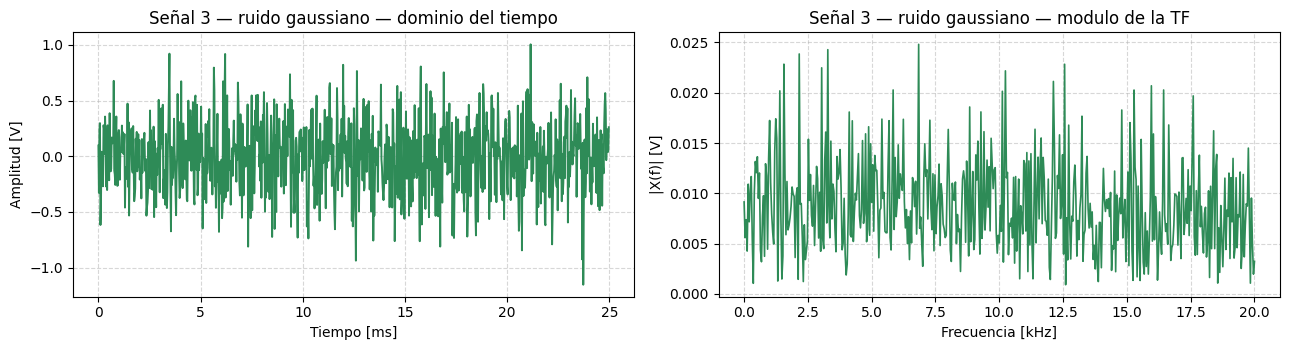

Potencia media P = 0.0978 W   |   Valor medio (DC) = -0.0091 V   |   Varianza = 0.0978 W


In [41]:
var_ruido = 0.1
sigma     = np.sqrt(var_ruido)

xx3 = rng.normal(loc=0.0, scale=sigma, size=N)

print(f'sigma = sqrt({var_ruido}) = {sigma:.4f} V')
analizar(xx3, 'Señal 3 — ruido gaussiano', color='seagreen', ciclos=None)

**Análisis — Señal 3**

| Parámetro | Valor |
|---|---|
| Período | aperiódica |
| Muestras totales | $N = 1000$ |
| Valor medio | $\approx 0$ V ✔ |
| Varianza = potencia media | $\approx 0{,}1$ W ✔ |
| Tipo de señal | Potencia |

### 1.4 — Ruido uniformemente distribuido: media 0 V, varianza 0,1 W

Para una distribución uniforme en $[-a,\ a]$:

$$\mu = 0, \qquad \sigma^2 = \frac{(2a)^2}{12} = \frac{a^2}{3}$$

Despejando el semiancho para la varianza pedida:

$$a = \sqrt{3\sigma^2} = \sqrt{3 \cdot 0{,}1} = \sqrt{0{,}3} \approx 0{,}5477\ \text{V}$$

a = sqrt(3*0.1) = 0.5477 V  ->  x4 uniforme en [-0.5477, 0.5477]


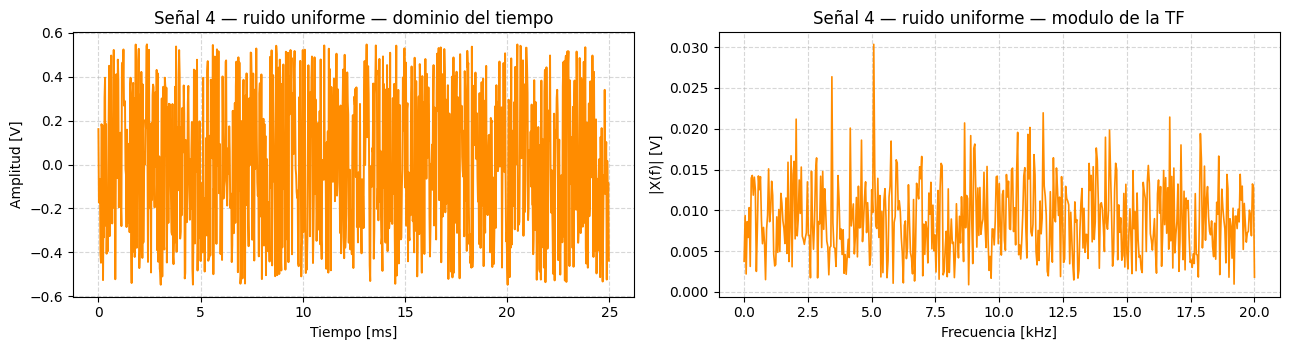

Potencia media P = 0.1006 W   |   Valor medio (DC) = +0.0038 V   |   Varianza = 0.1006 W


In [42]:
a_unif = np.sqrt(3 * var_ruido)

xx4 = rng.uniform(low=-a_unif, high=a_unif, size=N)

print(f'a = sqrt(3*{var_ruido}) = {a_unif:.4f} V  ->  x4 uniforme en [{-a_unif:.4f}, {a_unif:.4f}]')
analizar(xx4, 'Señal 4 — ruido uniforme', color='darkorange', ciclos=None)

**Análisis — Señal 4**

| Parámetro | Valor |
|---|---|
| Período | aperiódica |
| Muestras totales | $N = 1000$ |
| Rango de amplitudes | $[-0{,}5477,\ +0{,}5477]$ V |
| Valor medio | $\approx 0$ V |
| Varianza = potencia media | $\approx 0{,}1$ W |
| Tipo de señal | Potencia |

### 1.5 — Pulso rectangular de 2 kHz, 1 W de potencia y ciclo de actividad 50 %

Se usa square, que genera una onda cuadrada bipolar alternando entre $+A$ y $-A$. Su potencia media es

$$P = \frac{1}{T_0}\int_0^{T_0} x^2(t)\,dt = A^2$$

porque $|x| = A$ en todo instante. Entonces $A = \sqrt{P} = 1$ V da exactamente 1 W.

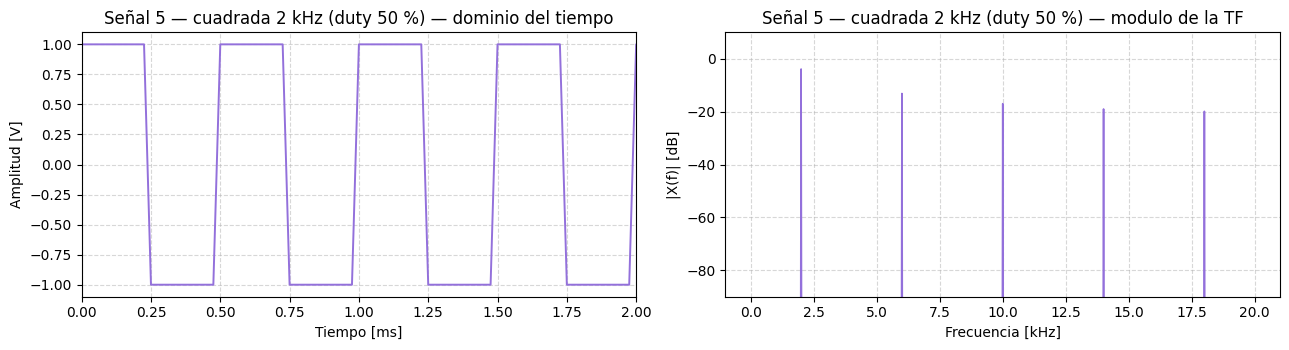

Potencia media P = 1.0000 W   |   Valor medio (DC) = +0.0000 V   |   Varianza = 1.0000 W


In [43]:
A5   = 1.0
duty = 0.5

xx5 = A5 * square(2 * np.pi * f0 * (tt + ts/2), duty=duty)

analizar(xx5, 'Señal 5 — cuadrada 2 kHz (duty 50 %)', color='mediumpurple', escala='dB')

**Análisis — Señal 5**

| Parámetro | Valor |
|---|---|
| Período | $T_0 = 1/f_0 = 0{,}5$ ms |
| Muestras totales | $N = 1000$ |
| Muestras por período | 20 |
| Ciclo de actividad | 50 % |
| Potencia media | $P = A^2 = 1$ W ✔ |
| Tipo de señal | Potencia |

## Bonus - Análisis de otra señal

### Diente de Sierra

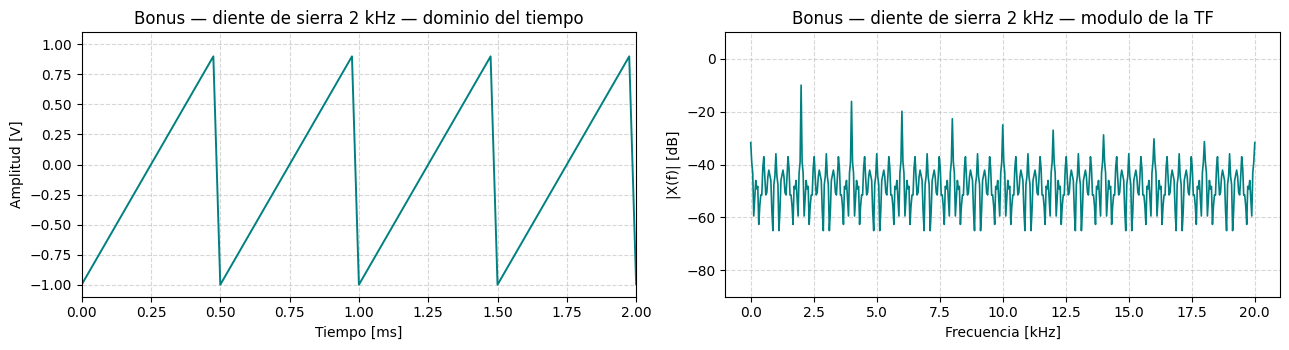

Potencia media P = 0.3350 W   |   Valor medio (DC) = -0.0260 V   |   Varianza = 0.3343 W


In [44]:
xx_saw = sawtooth(2 * np.pi * f0 * tt, width=1.0)

analizar(xx_saw, 'Bonus — diente de sierra 2 kHz', color='teal', escala='dB')

**Análisis**

| Parámetro | Valor |
|---|---|
| Período | $T_0 = 1/f_0 = 0{,}5$ ms |
| Muestras totales | $N = 1000$ |
| Muestras por período | 20 |
| Amplitud | rampa de $-A$ a $+A$, con $A = 1$ V |
| Valor medio | $-0{,}026$ V |
| Potencia media | $P = 0{,}335$ W $\approx A^2/3$ |
| Tipo de señal | Potencia |


### Pulso rectangular único

Las cinco señales de la consigna son de potencia: duran indefinidamente, su energía es infinita y lo que está definido es la potencia media. 

Un pulso único es el caso complementario: dura un tiempo finito, así que su energía es finita y su potencia media es nula.

$$x_6(t) = A\,\Pi\!\left(\frac{t - t_c}{\tau}\right), \qquad E = A^2\tau, \qquad P = \lim_{T\to\infty}\frac{E}{T} = 0$$

Con $A = 1$ V y $\tau = T_0/2 = 0{,}25$ ms resulta $E = 0{,}25$ mJ. Su transformada ya no es un conjunto de rayas sino una función continua:

$$|G(f)| = A\,\tau\,\left|\operatorname{sinc}(f\tau)\right|, \qquad \text{ceros en } f = \frac{k}{\tau} = k \cdot 4\ \text{kHz}$$

La posición $t_c$ del pulso afecta solo la fase, no el módulo de la TF.

Ancho: tau = 0.25 ms = 10 muestras   |   Energia E = A^2*tau = 0.2500 mJ
Primer cero del espectro: 1/tau = 4000 Hz


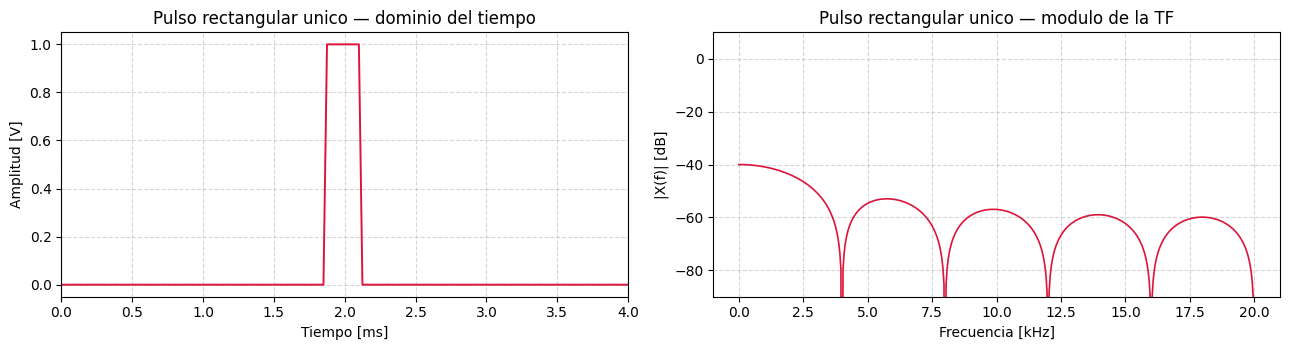

Potencia media P = 0.0100 W   |   Valor medio (DC) = +0.0100 V   |   Varianza = 0.0099 W


In [ ]:
A6  = 1.0
tau = T0 / 2
t_c = 4 * T0

xx6 = A6 * ((tt >= t_c - tau / 2) & (tt < t_c + tau / 2)).astype(float)

E6 = np.sum(np.abs(xx6) ** 2) * ts

print(f'Ancho: tau = {tau*1e3:.2f} ms = {int(xx6.sum()):d} muestras'
      f'   |   Energia E = A^2*tau = {E6*1e3:.4f} mJ')
print(f'Primer cero del espectro: 1/tau = {1/tau:.0f} Hz')

analizar(xx6, 'Pulso rectangular unico', color='crimson', ciclos=8, escala='dB')

**Análisis**

| Parámetro | Valor |
|---|---|
| Período | aperiódica |
| Duración | $\tau = T_0/2 = 0{,}25$ ms (10 muestras) |
| Muestras totales | $N = 1000$ |
| Amplitud | $A = 1$ V |
| Energía | $E = A^2\tau = 0{,}25$ mJ ✔ |
| Potencia media | $P = 0$ |
| Primer cero del espectro | $1/\tau = 4$ kHz |
| Tipo de señal | Energía |

## Ejercicio 2 — Resolución analítica


**Carilla 1**

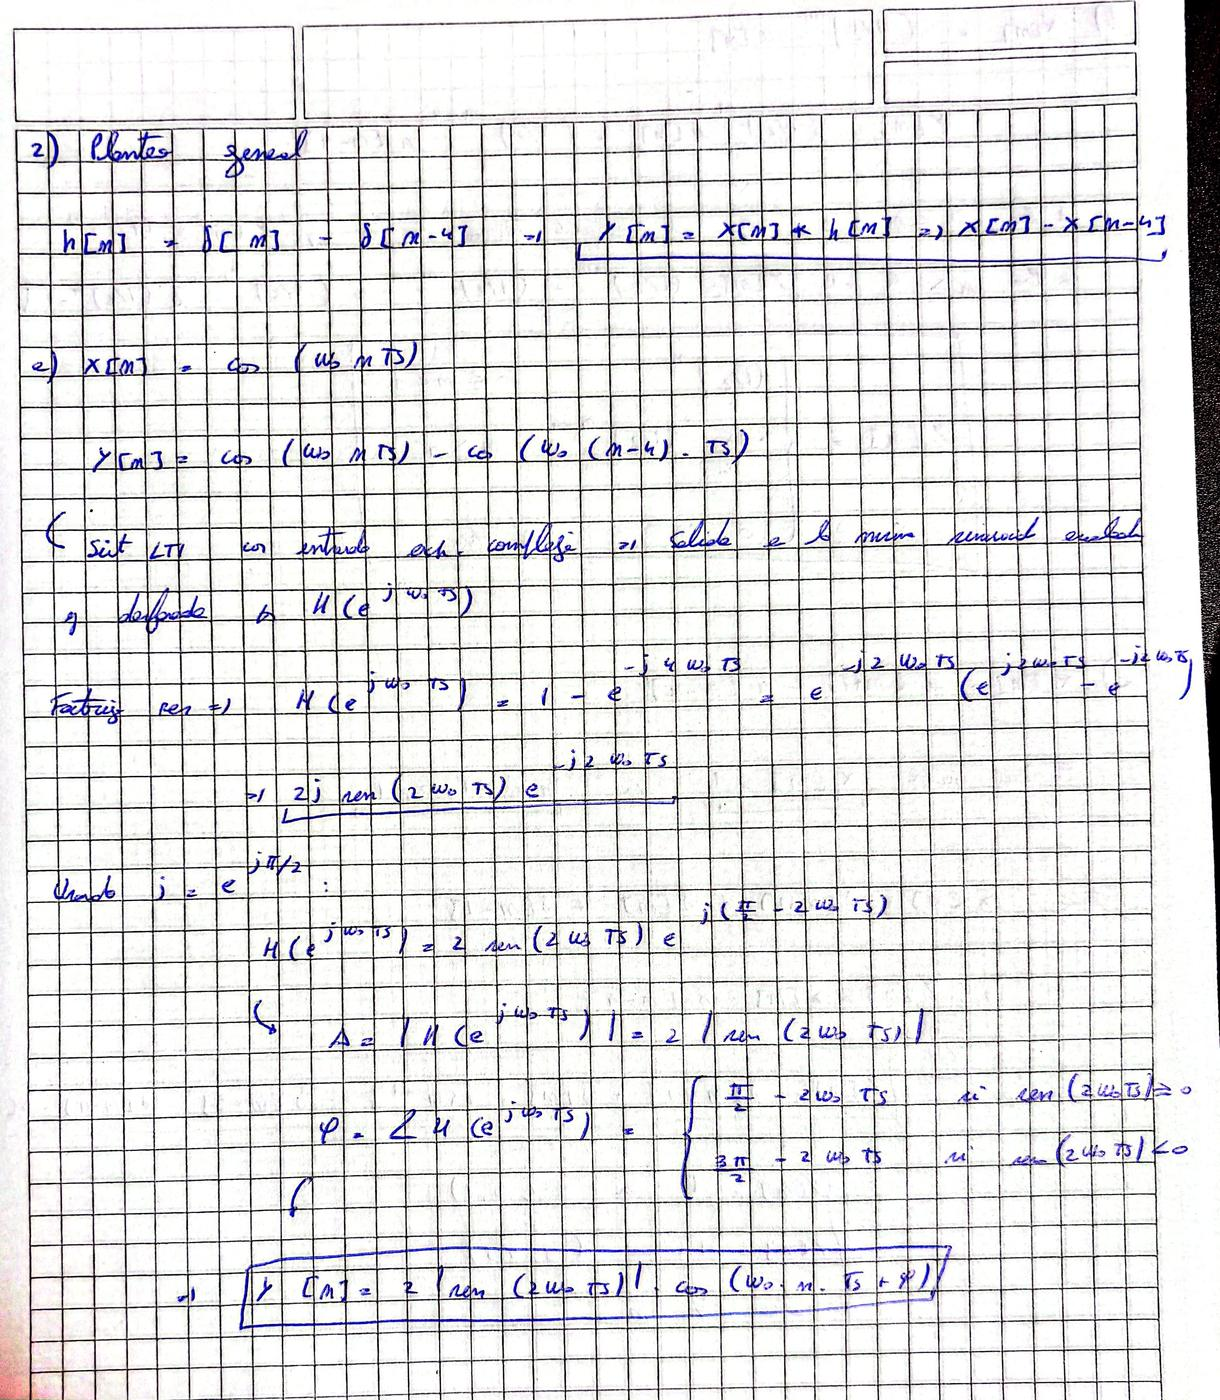

**Carilla 2**

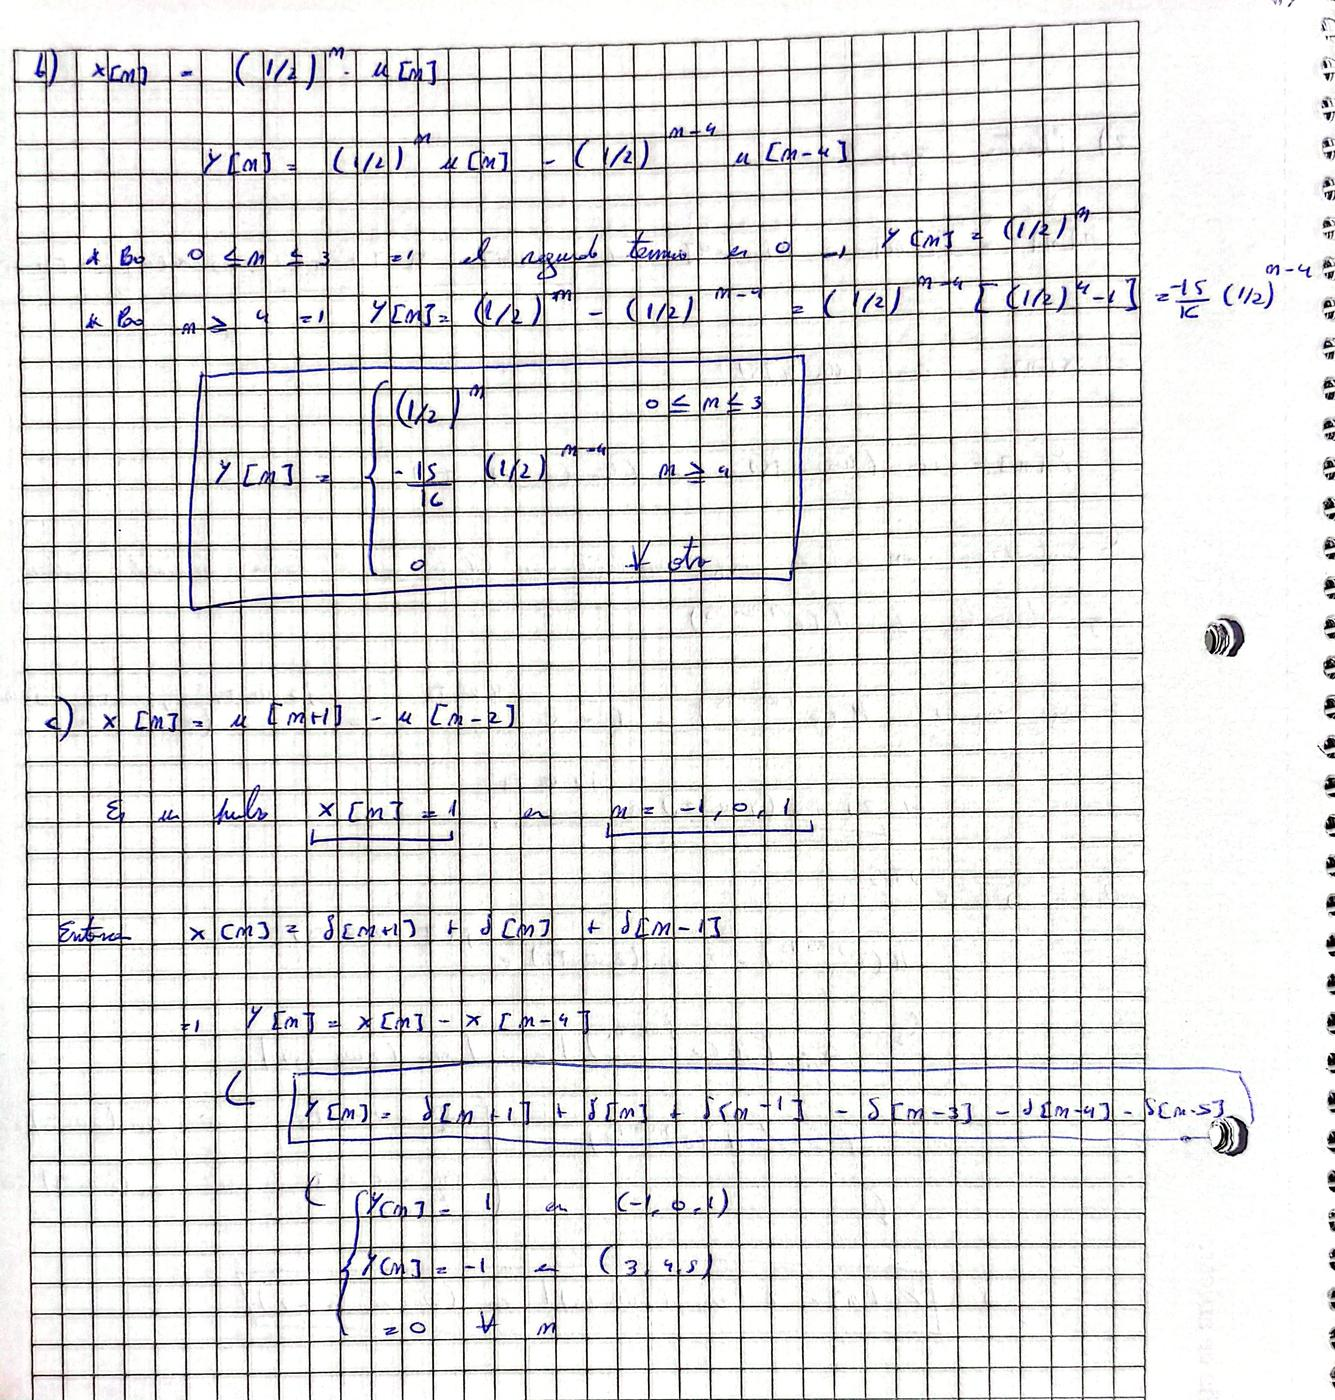


## Ejercicio 2 - Bonus

## DFT de $y[n]$ para $N = 8$

Planteo analítico. Con $N = 8$ la DFT de la respuesta al impulso es especialmente simple:

$$H[k] = \sum_{n=0}^{7} h[n]\,e^{-j2\pi kn/8} = 1 - e^{-j2\pi \cdot 4k/8} = 1 - e^{-j\pi k} = 1 - (-1)^k$$

$$\boxed{\;H[k] = \begin{cases} 0 & k \ \text{par} \\ 2 & k \ \text{impar}\end{cases}\;}$$

El sistema, visto en 8 puntos, anula todos los bins pares y duplica los impares. Como en el dominio de la DFT la convolución circular se transforma en producto:

$$Y[k] = X[k]\cdot H[k] = \begin{cases} 0 & k \ \text{par} \\ 2\,X[k] & k \ \text{impar}\end{cases}$$

In [ ]:
N8 = 8
k8 = np.arange(N8)
n8 = np.arange(N8)

h8 = np.zeros(N8); h8[0] = 1.0; h8[4] = -1.0
H8 = np.fft.fft(h8)

print('H[k] = 1 - (-1)^k   ->  0 en los bins pares, 2 en los impares')
print('  k    :', '  '.join(f'{v:6d}' for v in k8))
print('  |H[k]|:', '  '.join(f'{abs(v):6.2f}' for v in H8))
print()

def dft8(x8, nombre):
    # convolucion circular
    X8 = np.fft.fft(x8)
    y8 = np.real(np.fft.ifft(X8 * H8))
    y8_dir = x8 - np.roll(x8, 4)
    Y8 = np.fft.fft(y8)
    print(f'--- {nombre} ---')
    print('  x[n]  :', '  '.join(f'{v:+7.3f}' for v in x8))
    print('  y[n]  :', '  '.join(f'{v:+7.3f}' for v in y8))
    print('  |Y[k]|:', '  '.join(f'{abs(v):7.3f}' for v in Y8))
    print(f'  Producto en frecuencia == resta directa: {np.allclose(y8, y8_dir)}')
    print(f'  Bins pares de Y[k] nulos: {np.allclose(Y8[0::2], 0)}\n')
    return y8, Y8

H[k] = 1 - (-1)^k   ->  0 en los bins pares, 2 en los impares
  k    :      0       1       2       3       4       5       6       7
  |H[k]|:   0.00    2.00    0.00    2.00    0.00    2.00    0.00    2.00



**Conclusiones DFT**

- El resultado clave es que $H[k] = 1-(-1)^k$ anula todos los bins pares. Eso se ve en los tres gráficos: $|Y[k]| = 0$ para $k = 0, 2, 4, 6$ sin importar cuál sea la entrada. En particular $Y[0] = 0$ siempre, lo que significa que el sistema elimina la componente de continua — algo esperable en un sistema que resta la señal consigo misma retardada.
- Con $N = 8$, el retardo de 4 muestras es exactamente medio período de la ventana de análisis, y por eso el filtro cancela las frecuencias que completan un número entero de ciclos en 4 muestras.